In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargar el dataset
df = pd.read_csv("california_cities.csv")

# Mostrar las primeras filas
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [5]:
df.describe()

,Unnamed: 0,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
count,482.000000,482.000000,482.000000,434.000000,470.000000,4.820000e+02,480.000000,482.000000,481.000000,477.000000,478.000000,478.000000,477.000000
mean,240.500000,36.095088,-119.837714,180.416705,567.168723,6.489493e+04,18.442183,16.840981,1.589630,46.753283,43.547021,3.125178,5.301801
std,139.285678,2.298006,2.147676,309.531825,1001.265722,2.032041e+05,36.363230,32.694647,9.490386,90.972269,84.933022,11.562269,14.656428
min,0.000000,32.578333,-124.263333,-34.000000,-180.000000,1.000000e+00,0.314000,0.314000,0.000000,0.813000,0.813000,0.000000,0.000000
25%,120.250000,33.977292,-121.954931,22.000000,69.000000,1.090200e+04,3.708250,3.506500,0.000000,9.551000,9.025000,0.000250,0.000000
50%,240.500000,36.204722,-119.708611,67.000000,200.000000,2.905750e+04,9.093000,8.362000,0.029000,23.551000,21.533000,0.078500,0.340000
75%,360.750000,37.886667,-117.977292,173.500000,515.000000,6.646650e+04,19.878250,19.090000,0.244000,51.772000,49.322000,0.623250,1.870000
max,481.000000,41.965000,-114.596389,2402.000000,7880.000000,3.884307e+06,503.000000,469.000000,185.020000,1302.000000,1214.000000,122.270000,84.580000


In [6]:
# Eliminar filas con valores nulos
df = df.dropna()

# Comprobar que ya no hay nulos
df.isnull().sum()

Unnamed: 0            0
city                  0
latd                  0
longd                 0
elevation_m           0
elevation_ft          0
population_total      0
area_total_sq_mi      0
area_land_sq_mi       0
area_water_sq_mi      0
area_total_km2        0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64

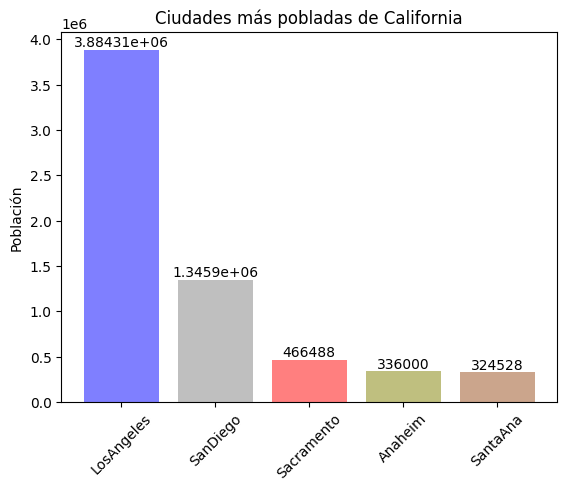

In [ ]:
#  5 ciudades más pobladas
top5 = df.sort_values("population_total", ascending=False).head(5)

# Colores COGER EL AZUL el gris el rojo gris verde oliva y marron
colors = [
    (0, 0, 1, 0.5),      # azul
    (0.5, 0.5, 0.5, 0.5),# gris
    (1, 0, 0, 0.5),      # rojo
    (0.5, 0.5, 0, 0.5),  # aceituna
    (0.6, 0.3, 0.1, 0.5) # marrón
]

plt.figure()
bars = plt.bar(top5["city"], top5["population_total"], color=colors)

# Añadir etiquetas 
plt.bar_label(bars, label_type="edge")

plt.title("Ciudades más pobladas de California")
plt.ylabel("Población")
plt.xticks(rotation=45)
plt.show()

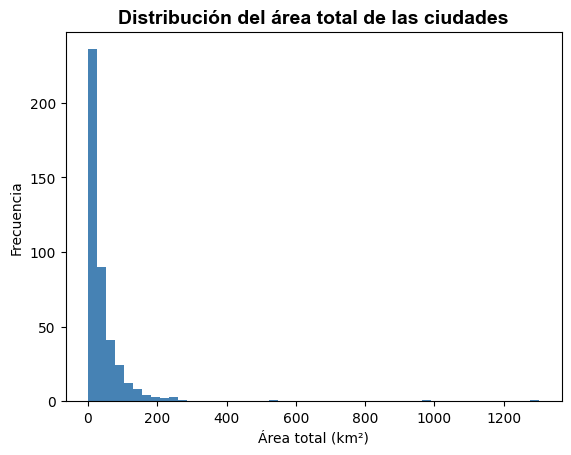

In [8]:
plt.figure()
plt.hist(df["area_total_km2"], bins=50, color="steelblue")

plt.title(
    "Distribución del área total de las ciudades",
    fontname="Arial",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Área total (km²)")
plt.ylabel("Frecuencia")
plt.show()

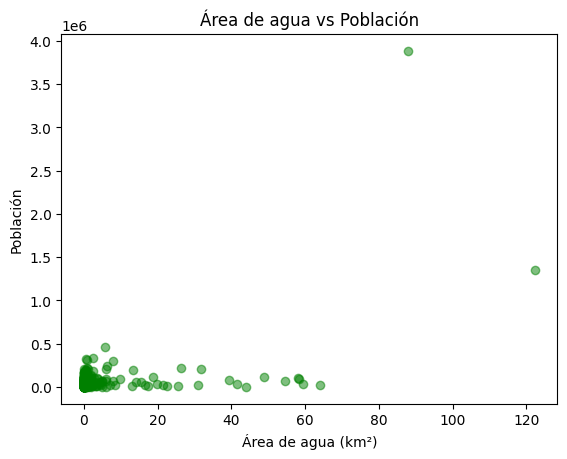

In [9]:
plt.figure()
plt.scatter(
    df["area_water_km2"],
    df["population_total"],
    color="green",
    alpha=0.5
)

plt.xlabel("Área de agua (km²)")
plt.ylabel("Población")
plt.title("Área de agua vs Población")
plt.show()

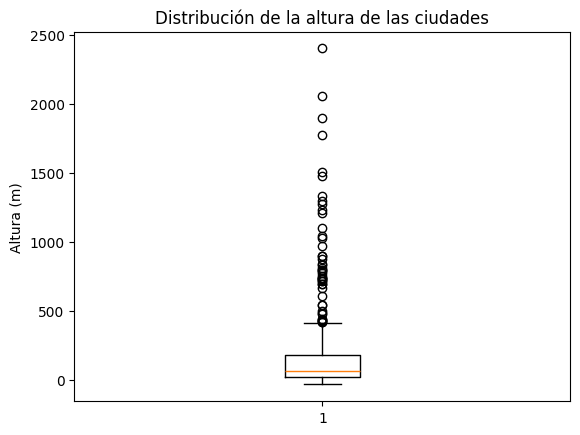

In [10]:
plt.figure()
plt.boxplot(df["elevation_m"])
plt.ylabel("Altura (m)")
plt.title("Distribución de la altura de las ciudades")
plt.show()

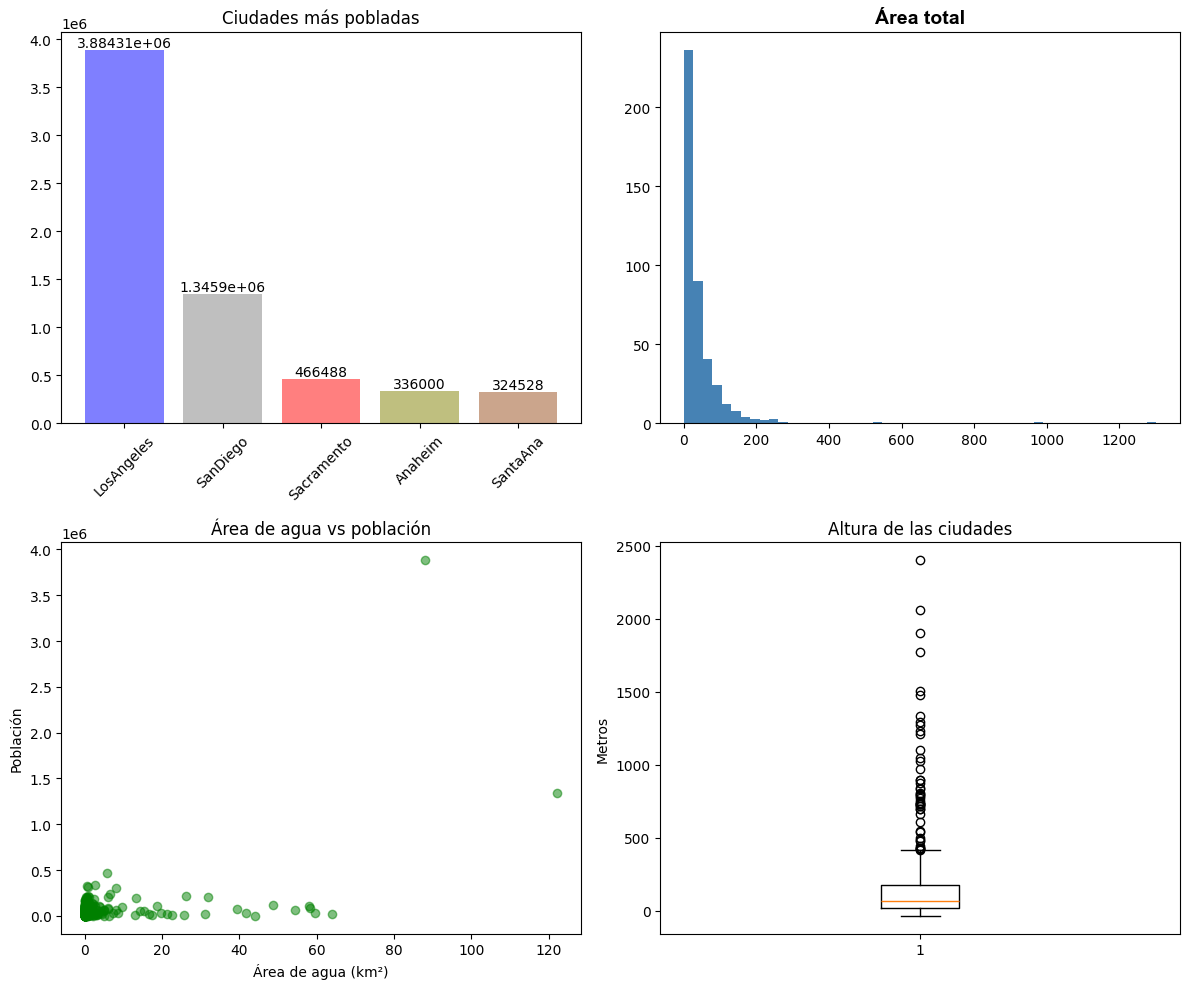

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# --- Gráfico 1: Barras ---
top5 = df.sort_values("population_total", ascending=False).head(5)
colors = [
    (0, 0, 1, 0.5),
    (0.5, 0.5, 0.5, 0.5),
    (1, 0, 0, 0.5),
    (0.5, 0.5, 0, 0.5),
    (0.6, 0.3, 0.1, 0.5)
]

bars = axs[0, 0].bar(top5["city"], top5["population_total"], color=colors)
axs[0, 0].bar_label(bars)
axs[0, 0].set_title("Ciudades más pobladas")
axs[0, 0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Histograma ---
axs[0, 1].hist(df["area_total_km2"], bins=50, color="steelblue")
axs[0, 1].set_title(
    "Área total",
    fontname="Arial",
    fontsize=14,
    fontweight="bold"
)

# --- Gráfico 3: Scatter ---
axs[1, 0].scatter(
    df["area_water_km2"],
    df["population_total"],
    color="green",
    alpha=0.5
)
axs[1, 0].set_title("Área de agua vs población")
axs[1, 0].set_xlabel("Área de agua (km²)")
axs[1, 0].set_ylabel("Población")

# --- Gráfico 4: Boxplot ---
axs[1, 1].boxplot(df["elevation_m"])
axs[1, 1].set_title("Altura de las ciudades")
axs[1, 1].set_ylabel("Metros")

plt.tight_layout()
plt.show()

In [12]:
plt.savefig("practica_obligatoria.png", dpi=300)

<Figure size 640x480 with 0 Axes>